<a href="https://colab.research.google.com/github/EgiNHardo/EgiNHardo-Proyecto1/blob/main/DIAGRAMA_PRISMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Para descargar desde archivos de Colab

In [1]:
# ──────────────────────────────────────────────────────────────
# Notebook de Análisis Bibliométrico + Diagrama PRISMA
# ──────────────────────────────────────────────────────────────

# Paso 1: Subir archivo
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = next(iter(uploaded))

# Cargar base de datos de Scopus
df = pd.read_csv(filename, encoding='utf-8')

# Paso 2: Instalar librerías necesarias
!pip install graphviz
import graphviz
from graphviz import Digraph

# Paso 3: Aplicar filtros estilo PRISMA

# Registro total
registros_identificados = df.shape[0]

# Eliminar duplicados por título
df_no_duplicados = df.drop_duplicates(subset='Title')
duplicados_eliminados = registros_identificados - df_no_duplicados.shape[0]

# Filtrar por tipo de documento: 'Article'
if 'Document Type' in df_no_duplicados.columns:
    df_tipo = df_no_duplicados[df_no_duplicados['Document Type'] == 'Article']
    excluidos_tipo = df_no_duplicados.shape[0] - df_tipo.shape[0]
else:
    df_tipo = df_no_duplicados.copy()
    excluidos_tipo = 0

# Filtrar por idioma: 'English'
if 'Language of Original Document' in df_tipo.columns:
    df_idioma = df_tipo[df_tipo['Language of Original Document'] == 'English']
    excluidos_idioma = df_tipo.shape[0] - df_idioma.shape[0]
else:
    df_idioma = df_tipo.copy()
    excluidos_idioma = 0

# Final: incluidos
incluidos_finales = df_idioma.shape[0]

# Paso 4: Crear diagrama PRISMA
prisma = Digraph(comment='PRISMA Flow Diagram', format='png')
prisma.attr(size='8,10', rankdir='TB', nodesep='0.5')

prisma.node('A', f'''Identificación:
Registros identificados en Scopus: {registros_identificados}''', shape='box')

prisma.node('B', f'''Filtrado:
Duplicados eliminados: {duplicados_eliminados}''', shape='box')

prisma.node('C', f'''Elegibilidad:
Excluidos por tipo de documento: {excluidos_tipo}
Excluidos por idioma: {excluidos_idioma}''', shape='box')

prisma.node('D', f'''Inclusión:
Estudios incluidos en el análisis final: {incluidos_finales}''', shape='box', style='filled', fillcolor='lightblue')

prisma.edge('A', 'B')
prisma.edge('B', 'C')
prisma.edge('C', 'D')

# Paso 5: Mostrar el diagrama
prisma.render('prisma_diagrama', view=True)


Saving SCOPUS.csv to SCOPUS.csv


'prisma_diagrama.png'

CÓDIGO COMPLETO — PRISMA + VISUAL EN GOOGLE COLAB

🔼 Sube tu archivo .csv exportado desde Scopus


Saving SCOPUS.csv to SCOPUS (1).csv
✅ Archivo cargado: SCOPUS (1).csv
📄 Registros originales: 110


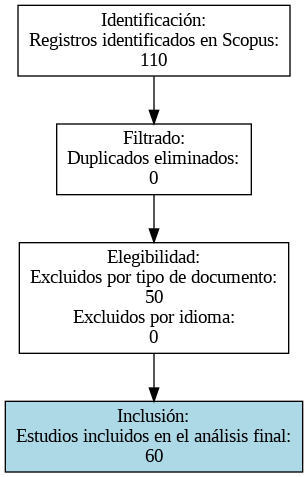

In [2]:
# ════════════════════════════════════════════════
# PRISMA Flow Diagram Generator - Google Colab
# ════════════════════════════════════════════════

# Paso 1: Subir archivo .csv de Scopus
from google.colab import files
import pandas as pd

print("🔼 Sube tu archivo .csv exportado desde Scopus")
uploaded = files.upload()
filename = next(iter(uploaded))

# Leer archivo CSV
df = pd.read_csv(filename, encoding='utf-8')
print(f"✅ Archivo cargado: {filename}")
print(f"📄 Registros originales: {df.shape[0]}")

# Paso 2: Instalar librerías necesarias
!pip install -q graphviz

# Paso 3: Importar librerías
from graphviz import Digraph
import IPython.display as display

# Paso 4: Aplicar filtros tipo PRISMA
registros_identificados = df.shape[0]

# Eliminar duplicados
df_no_duplicados = df.drop_duplicates(subset='Title')
duplicados_eliminados = registros_identificados - df_no_duplicados.shape[0]

# Filtrar por tipo de documento
if 'Document Type' in df_no_duplicados.columns:
    df_tipo = df_no_duplicados[df_no_duplicados['Document Type'] == 'Article']
    excluidos_tipo = df_no_duplicados.shape[0] - df_tipo.shape[0]
else:
    df_tipo = df_no_duplicados.copy()
    excluidos_tipo = 0

# Filtrar por idioma
if 'Language of Original Document' in df_tipo.columns:
    df_idioma = df_tipo[df_tipo['Language of Original Document'] == 'English']
    excluidos_idioma = df_tipo.shape[0] - df_idioma.shape[0]
else:
    df_idioma = df_tipo.copy()
    excluidos_idioma = 0

# Resultados finales
incluidos_finales = df_idioma.shape[0]

# Paso 5: Crear diagrama PRISMA
prisma = Digraph(comment='PRISMA Flow Diagram', format='png')
prisma.attr(size='8,10', rankdir='TB', nodesep='0.7')

# Nodos del diagrama
prisma.node('A', f'''Identificación:
Registros identificados en Scopus:
{registros_identificados}''', shape='box')

prisma.node('B', f'''Filtrado:
Duplicados eliminados:
{duplicados_eliminados}''', shape='box')

prisma.node('C', f'''Elegibilidad:
Excluidos por tipo de documento:
{excluidos_tipo}
Excluidos por idioma:
{excluidos_idioma}''', shape='box')

prisma.node('D', f'''Inclusión:
Estudios incluidos en el análisis final:
{incluidos_finales}''', shape='box', style='filled', fillcolor='lightblue')

# Conectar nodos
prisma.edge('A', 'B')
prisma.edge('B', 'C')
prisma.edge('C', 'D')

# Paso 6: Renderizar y mostrar el diagrama en Colab
output_path = 'prisma_diagrama'
prisma.render(output_path, format='png', cleanup=True)

# Mostrar imagen en Colab
from IPython.display import Image
display.display(Image(filename=output_path + '.png'))
